# SequoIA classification benchmark

Extract HAL metadata, audit missing fields, compare lexical and semantic representations with supervised, zero-shot, unsupervised, and semi-supervised methods, then export statistics and a PDF for manual review.

## 1. Setup

In [15]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.semi_supervised import LabelSpreading
from sklearn.svm import LinearSVC

WORKSPACE = Path("/home/formation2026/Bureau/veille_test")
sys.path.insert(0, str(WORKSPACE))
sys.modules.pop("hal_sequoia_extractor", None)
from hal_sequoia_extractor import SEQUOIA_AXES, SEQUOIA_SAXES

RANDOM_STATE = 42
USE_PRETRAINED_SEMANTIC = True
MPNET_ENCODER = "sentence-transformers/all-mpnet-base-v2"
MPNET_CLASSIFIER = "model.similarity"
SEMANTIC_MODEL_NAMES = [MPNET_ENCODER]

SUBAXIS_NAMES = [
    f"{pillar} :: {subaxis}"
    for pillar, subaxes in SEQUOIA_SAXES.items()
    for subaxis in subaxes
]
SUBAXIS_TEXTS = [
    "; ".join(keywords)
    for subaxes in SEQUOIA_SAXES.values()
    for keywords in subaxes.values()
]

## 2. Extract the complete HAL collection

In [16]:
# API extraction kept for reference; the benchmark now uses the curated CSV labels and metadata.
# docs = fetch_all()
# df = pd.DataFrame(docs)

csv_columns = [
    "halId_s", "title", "abstract", "journal", "keywords", "main_pillar",
    "url", "doi", "authors", "year", "doc_type", "language", "domains",
]
df = pd.read_csv(WORKSPACE / "hal_sequoia.csv", usecols=lambda column: column in csv_columns, dtype={"halId_s": str})
df = df.rename(columns={
    "title": "title_s",
    "abstract": "abstract_s",
    "journal": "journalTitle_s",
    "keywords": "keyword_s",
    "doc_type": "docType_s",
})
print(f"Loaded {len(df):,} curated SEQUOIA records from hal_sequoia.csv")
df.head(3)

Loaded 1,404 curated SEQUOIA records from hal_sequoia.csv


,halId_s,title_s,authors,year,docType_s,language,journalTitle_s,keyword_s,abstract_s,url,doi,main_pillar,domains
0,hal-04164424,Unravelling individual rhythmic abilities usin...,Simone Dalla Bella | Stefan Janaqi | Charles-E...,2024,Article,Anglais,Scientific Reports,Human behaviour | Psychology,Humans can easily extract the rhythm of a comp...,https://imt-atlantique.hal.science/hal-04164424v1,10.1038/s41598-024-51257-7,Core AI,scco.neur
1,hal-05201458,Apprentissage par transfert pour la détection ...,Lucie Jean-Labadye | Gabriel Dubus | Dorian Ca...,2025,Communication,Français,NaN,Bioacoustics | Passive acoustic monitoring | B...,Les tâches de détection et de classification d...,https://hal.science/hal-05201458v1,NaN,Core AI,info.info-sd | info.info-lg | sde.ie | spi.acou
2,hal-04817115,Beyond Total Locking: Demonstrating and Measur...,Eloïse Delolme | Viktor Fischer | Florent Bern...,2024,Communication,Anglais,NaN,Standards | Field programmable gate arrays | S...,Ring oscillator-based true random number gener...,https://hal.science/hal-04817115v1,10.1109/socc62300.2024.10737851,IA & cybersécurité,spi


## 3. Data audit and text preparation

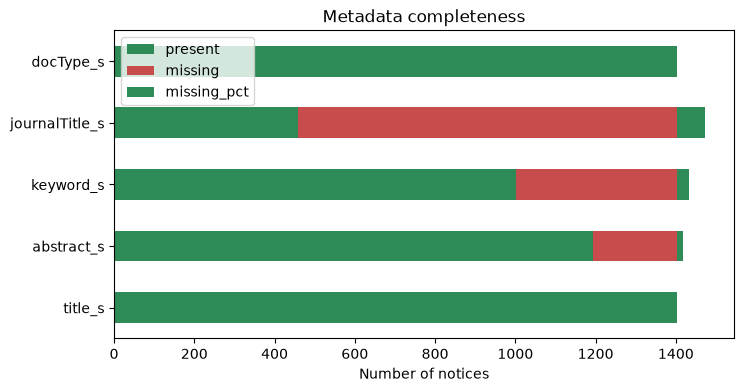

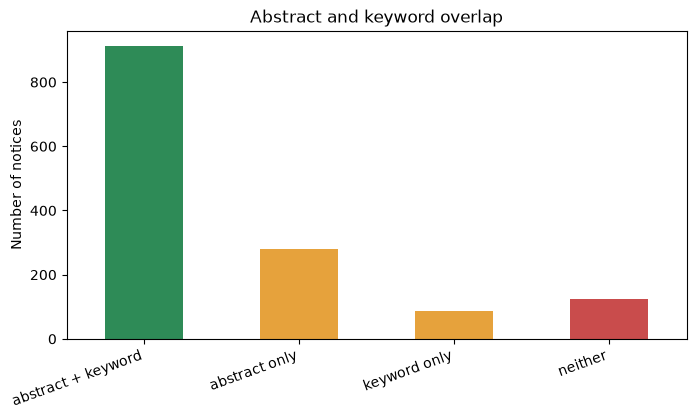

Text available: 1,404/1,404


In [17]:
def is_empty(value):
    if value is None:
        return True
    if isinstance(value, float) and pd.isna(value):
        return True
    if isinstance(value, (list, str)):
        return len(value) == 0
    return False


def join_field(value):
    if isinstance(value, list):
        return " ".join(str(item) for item in value)
    return "" if is_empty(value) else str(value)


audit_fields = [field for field in ["title_s", "abstract_s", "keyword_s", "journalTitle_s", "docType_s", "domainAllCode_s"] if field in df.columns]
audit = pd.DataFrame({"present": [df[field].apply(lambda value: not is_empty(value)).sum() for field in audit_fields], "missing": [df[field].apply(is_empty).sum() for field in audit_fields]}, index=audit_fields)
audit["missing_pct"] = (audit["missing"] / len(df) * 100).round(1)
audit.plot(kind="barh", stacked=True, color=["#2E8B57", "#C94C4C"], figsize=(8, 4), title="Metadata completeness")
plt.xlabel("Number of notices")
plt.show()

df["has_abstract"] = ~df["abstract_s"].apply(is_empty)
df["has_keyword"] = ~df["keyword_s"].apply(is_empty)
coverage = pd.Series(np.select([df["has_abstract"] & df["has_keyword"], df["has_abstract"] & ~df["has_keyword"], ~df["has_abstract"] & df["has_keyword"], ~df["has_abstract"] & ~df["has_keyword"]], ["abstract + keyword", "abstract only", "keyword only", "neither"], default="neither")).value_counts()
coverage.reindex(["abstract + keyword", "abstract only", "keyword only", "neither"]).plot(kind="bar", color=["#2E8B57", "#E6A23C", "#E6A23C", "#C94C4C"], figsize=(8, 4), title="Abstract and keyword overlap")
plt.ylabel("Number of notices")
plt.xticks(rotation=20, ha="right")
plt.show()

text_fields = ("title_s", "abstract_s", "keyword_s", "journalTitle_s")
df["text_for_classification"] = df.apply(
    lambda row: " ".join(join_field(row.get(field)) for field in text_fields if field in df.columns),
    axis=1,
)
print(f"Text available: {(df['text_for_classification'].str.strip() != '').sum():,}/{len(df):,}")

## 4. Baseline and benchmark configuration

In [18]:
axis_names = list(SEQUOIA_AXES.keys())

pillar_to_axis = {
    "Core AI": axis_names[0],
    "IA & cybersécurité": axis_names[1],
    "IA & environnement": axis_names[2],
    "Non classifié": "no class",
}

df["main_pillar_axis"] = df["main_pillar"].map(pillar_to_axis).fillna("no class")
df["baseline_axis"] = df["main_pillar_axis"]

print(f"CSV pillar labels available: {(df['main_pillar'] != '').sum():,}/{len(df):,}")
print(df["baseline_axis"].value_counts(dropna=False))

CSV pillar labels available: 1,404/1,404
baseline_axis
no class                         575
Core AI                          549
AI, Environment and Ocean        164
AI, Cybersecurity and Defense    116
Name: count, dtype: int64


In [19]:
representations = {
    "word_tfidf": TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2),
    "char_tfidf": TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2),
    "word_char_tfidf": FeatureUnion([("word", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2)), ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2))]),
}
classifiers = {
    "logistic_regression": lambda: LogisticRegression(max_iter=1500, class_weight="balanced"),
    "linear_svm": lambda: LinearSVC(class_weight="balanced"),
    "sgd_classifier": lambda: SGDClassifier(
        loss="log_loss",
        max_iter=2000,
        tol=1e-3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "mlp_small": lambda: MLPClassifier(
        hidden_layer_sizes=(32,),
        alpha=1e-3,
        batch_size=32,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=RANDOM_STATE,
    ),
}

# Train/test labels come from hal_sequoia.csv main_pillar, not from cosine similarity.
labeled = df[df["baseline_axis"] != "no class"].copy()
X_train, X_test, y_train, y_test = train_test_split(
    labeled["text_for_classification"],
    labeled["baseline_axis"],
    test_size=0.25,
    stratify=labeled["baseline_axis"],
    random_state=RANDOM_STATE,
)
print(f"Train/test source rows: {len(labeled):,} labeled pillar records")

Train/test source rows: 829 labeled pillar records


## 5. Lexical supervised methods

In [20]:
benchmark_rows = []
all_predictions = {
    "baseline__main_pillar_csv": df["baseline_axis"].to_numpy(),
}
all_confidences = {
    "baseline__main_pillar_csv": (df["baseline_axis"] != "no class").astype(float).to_numpy(),
}
test_predictions = {}
for representation_name, representation in representations.items():
    for classifier_name, factory in classifiers.items():
        method = f"supervised__{representation_name}__{classifier_name}"
        test_model = Pipeline([("representation", clone(representation)), ("classifier", factory())]).fit(X_train, y_train)
        test_prediction = test_model.predict(X_test)
        test_predictions[method] = test_prediction
        report = classification_report(y_test, test_prediction, output_dict=True)
        benchmark_rows.append({"method": method, "representation_model": representation_name, "learning_type": "supervised", "classifier": classifier_name, "test_accuracy": accuracy_score(y_test, test_prediction), "macro_f1": report["macro avg"]["f1-score"], "test_count": len(y_test)})
        full_model = Pipeline([("representation", clone(representation)), ("classifier", factory())]).fit(labeled["text_for_classification"], labeled["baseline_axis"])
        full_features = full_model.named_steps["representation"].transform(df["text_for_classification"])
        all_predictions[method] = full_model.predict(df["text_for_classification"])
        classifier = full_model.named_steps["classifier"]
        all_confidences[method] = classifier.predict_proba(full_features).max(axis=1) if hasattr(classifier, "predict_proba") else classifier.decision_function(full_features).max(axis=1)
lexical_results = pd.DataFrame(benchmark_rows)
lexical_results

,method,representation_model,learning_type,classifier,test_accuracy,macro_f1,test_count
0,supervised__word_tfidf__logistic_regression,word_tfidf,supervised,logistic_regression,0.879808,0.839687,208
1,supervised__word_tfidf__linear_svm,word_tfidf,supervised,linear_svm,0.875000,0.820781,208
2,supervised__word_tfidf__sgd_classifier,word_tfidf,supervised,sgd_classifier,0.875000,0.817118,208
3,supervised__word_tfidf__mlp_small,word_tfidf,supervised,mlp_small,0.817308,0.667442,208
4,supervised__char_tfidf__logistic_regression,char_tfidf,supervised,logistic_regression,0.899038,0.868548,208
5,supervised__char_tfidf__linear_svm,char_tfidf,supervised,linear_svm,0.894231,0.854777,208
6,supervised__char_tfidf__sgd_classifier,char_tfidf,supervised,sgd_classifier,0.903846,0.869128,208
7,supervised__char_tfidf__mlp_small,char_tfidf,supervised,mlp_small,0.841346,0.726064,208
8,supervised__word_char_tfidf__logistic_regression,word_char_tfidf,supervised,logistic_regression,0.894231,0.859531,208
9,supervised__word_char_tfidf__linear_svm,word_char_tfidf,supervised,linear_svm,0.889423,0.845024,208


## 6. Semantic, zero-shot, unsupervised, and semi-supervised methods

`SEMANTIC_MODEL_NAMES` contains the exact Hugging Face model identifiers. Set
`USE_PRETRAINED_SEMANTIC = True` to benchmark all of them. Every output keeps the full
model name in `representation_model` and in `method`, for example:

- `zero_shot__sentence-transformers/all-MiniLM-L6-v2`
- `supervised__sentence-transformers/all-MiniLM-L6-v2__linear_svm`
- `semi_supervised__sentence-transformers/all-MiniLM-L6-v2__label_spreading`

In [21]:
semantic_rows = []
semantic_test_predictions = {}

semantic_positions = df.index[df["baseline_axis"] != "no class"].to_numpy()
semantic_labels = df.loc[semantic_positions, "baseline_axis"].to_numpy()
train_positions, test_positions = train_test_split(
    np.arange(len(semantic_positions)),
    test_size=0.25,
    stratify=semantic_labels,
    random_state=RANDOM_STATE,
)
axis_codes = {axis: index for index, axis in enumerate(axis_names)}

if USE_PRETRAINED_SEMANTIC:
    from sentence_transformers import SentenceTransformer

    semantic_model_specs = [(model_name, SentenceTransformer(model_name)) for model_name in SEMANTIC_MODEL_NAMES]
else:
    semantic_model_specs = [("local/TF-IDF+TruncatedSVD", None)]

def similarity_scores(model, embeddings, comparison_embeddings):
    if model is None:
        return cosine_similarity(embeddings, comparison_embeddings)
    return model.similarity(embeddings, comparison_embeddings).cpu().numpy()

for model_name, semantic_model in semantic_model_specs:
    if semantic_model is not None:
        embeddings = semantic_model.encode(
            df["text_for_classification"].tolist(),
            normalize_embeddings=True,
            show_progress_bar=True,
        )
        axis_embeddings = semantic_model.encode(
            list(SEQUOIA_AXES.values()), normalize_embeddings=True
        )
    else:
        semantic_vectorizer = TfidfVectorizer(
            stop_words="english", ngram_range=(1, 2), min_df=2
        )
        semantic_tfidf = semantic_vectorizer.fit_transform(df["text_for_classification"])
        semantic_svd = TruncatedSVD(
            n_components=min(100, semantic_tfidf.shape[1] - 1),
            random_state=RANDOM_STATE,
        )
        embeddings = semantic_svd.fit_transform(semantic_tfidf)
        embeddings /= np.maximum(
            np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-12
        )
        axis_embeddings = semantic_svd.transform(
            semantic_vectorizer.transform(list(SEQUOIA_AXES.values()))
        )
        axis_embeddings /= np.maximum(
            np.linalg.norm(axis_embeddings, axis=1, keepdims=True), 1e-12
        )

    # Zero-shot: compare each article embedding directly with the three axis descriptions.
    zero_shot_similarity = similarity_scores(semantic_model, embeddings, axis_embeddings)
    zero_shot_confidence = zero_shot_similarity.max(axis=1)
    zero_shot_prediction = np.array(axis_names)[zero_shot_similarity.argmax(axis=1)]
    zero_shot_threshold = float(np.quantile(zero_shot_confidence, 0.25))
    zero_shot_prediction[zero_shot_confidence < zero_shot_threshold] = "no class"
    zero_shot_method = f"mpnet_similarity_classifier__{model_name}"
    all_predictions[zero_shot_method] = zero_shot_prediction
    all_confidences[zero_shot_method] = zero_shot_confidence

    # Supervised classifiers trained on baseline-labeled notices.
    for classifier_name, factory in classifiers.items():
        method = f"supervised__{model_name}__{classifier_name}"
        test_model = factory().fit(
            embeddings[semantic_positions][train_positions],
            semantic_labels[train_positions],
        )
        prediction = test_model.predict(embeddings[semantic_positions][test_positions])
        semantic_test_predictions[method] = prediction
        report = classification_report(
            semantic_labels[test_positions], prediction, output_dict=True
        )
        semantic_rows.append({
            "method": method,
            "representation_model": model_name,
            "learning_type": "supervised",
            "classifier": classifier_name,
            "test_accuracy": accuracy_score(semantic_labels[test_positions], prediction),
            "macro_f1": report["macro avg"]["f1-score"],
            "test_count": len(test_positions),
        })
        full_model = factory().fit(embeddings[semantic_positions], semantic_labels)
        all_predictions[method] = full_model.predict(embeddings)
        all_confidences[method] = (
            full_model.predict_proba(embeddings).max(axis=1)
            if hasattr(full_model, "predict_proba")
            else full_model.decision_function(embeddings).max(axis=1)
        )

    zero_shot_report = classification_report(
        df.loc[semantic_positions, "baseline_axis"],
        zero_shot_prediction[semantic_positions],
        output_dict=True,
        zero_division=0,
    )
    semantic_rows.append({
        "method": zero_shot_method,
        "representation_model": model_name,
        "learning_type": "zero-shot",
        "classifier": MPNET_CLASSIFIER,
        "test_accuracy": zero_shot_report["accuracy"],
        "macro_f1": zero_shot_report["macro avg"]["f1-score"],
        "test_count": len(semantic_positions),
    })

    # Unsupervised KMeans with cluster-to-axis mapping through the axis descriptions.
    semantic_kmeans = KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE).fit(embeddings)
    cluster_ids = semantic_kmeans.labels_
    cluster_axis_similarity = similarity_scores(
        semantic_model, semantic_kmeans.cluster_centers_, axis_embeddings
    )
    cluster_axis = {
        cluster: axis_names[cluster_axis_similarity[cluster].argmax()]
        for cluster in range(3)
    }
    cluster_confidence = similarity_scores(
        semantic_model, embeddings, semantic_kmeans.cluster_centers_
    )[np.arange(len(df)), cluster_ids]
    cluster_prediction = np.array([cluster_axis[cluster] for cluster in cluster_ids])
    cluster_prediction[cluster_confidence < np.median(cluster_confidence)] = "no class"
    kmeans_method = f"unsupervised__{model_name}__kmeans"
    all_predictions[kmeans_method] = cluster_prediction
    all_confidences[kmeans_method] = cluster_confidence
    semantic_rows.append({
        "method": kmeans_method,
        "representation_model": model_name,
        "learning_type": "unsupervised",
        "classifier": "kmeans",
        "test_accuracy": np.nan,
        "macro_f1": np.nan,
        "test_count": 0,
    })

    # Semi-supervised Label Spreading: only the training split is labeled.
    ssl_labels = np.full(len(semantic_positions), -1, dtype=int)
    ssl_labels[train_positions] = [axis_codes[label] for label in semantic_labels[train_positions]]
    ssl_model = LabelSpreading(
        kernel="knn", n_neighbors=15, alpha=0.2, max_iter=100
    ).fit(embeddings[semantic_positions], ssl_labels)
    ssl_prediction = np.array(axis_names)[ssl_model.transduction_[test_positions]]
    ssl_report = classification_report(
        semantic_labels[test_positions], ssl_prediction, output_dict=True
    )
    ssl_method = f"semi_supervised__{model_name}__label_spreading"
    semantic_rows.append({
        "method": ssl_method,
        "representation_model": model_name,
        "learning_type": "semi-supervised",
        "classifier": "label_spreading",
        "test_accuracy": accuracy_score(semantic_labels[test_positions], ssl_prediction),
        "macro_f1": ssl_report["macro avg"]["f1-score"],
        "test_count": len(test_positions),
    })
    all_labels = np.array([axis_codes.get(label, -1) for label in df["baseline_axis"]])
    ssl_full = LabelSpreading(
        kernel="knn", n_neighbors=15, alpha=0.2, max_iter=100
    ).fit(embeddings, all_labels)
    all_predictions[ssl_method] = np.array(axis_names)[ssl_full.transduction_]
    all_confidences[ssl_method] = ssl_full.label_distributions_.max(axis=1)

semantic_results = pd.DataFrame(semantic_rows)
semantic_results

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

,method,representation_model,learning_type,classifier,test_accuracy,macro_f1,test_count
0,supervised__sentence-transformers/all-mpnet-ba...,sentence-transformers/all-mpnet-base-v2,supervised,logistic_regression,0.927885,0.903187,208
1,supervised__sentence-transformers/all-mpnet-ba...,sentence-transformers/all-mpnet-base-v2,supervised,linear_svm,0.942308,0.923379,208
2,supervised__sentence-transformers/all-mpnet-ba...,sentence-transformers/all-mpnet-base-v2,supervised,sgd_classifier,0.937500,0.913480,208
3,supervised__sentence-transformers/all-mpnet-ba...,sentence-transformers/all-mpnet-base-v2,supervised,mlp_small,0.908654,0.869067,208
4,mpnet_similarity_classifier__sentence-transfor...,sentence-transformers/all-mpnet-base-v2,zero-shot,model.similarity,0.536791,0.447461,829
5,unsupervised__sentence-transformers/all-mpnet-...,sentence-transformers/all-mpnet-base-v2,unsupervised,kmeans,NaN,NaN,0
6,semi_supervised__sentence-transformers/all-mpn...,sentence-transformers/all-mpnet-base-v2,semi-supervised,label_spreading,0.894231,0.852033,208


## Hierarchical SequoIA pillar → sub-axis classification

Each article first keeps its assigned main pillar from `main_pillar`. The classifier then retrieves
only that pillar's entries from `SEQUOIA_SAXES`. Both representations include the article text plus
the pillar description, while every candidate axis representation includes its keywords plus the same
pillar description. Cosine similarity is computed only between the article and sub-axes inside its pillar.

In [ ]:
# Hierarchical classification: assigned pillar first, then only that pillar's sub-axes.
hierarchy_model_name = semantic_model_specs[-1][0]
hierarchy_pillar = df["baseline_axis"].to_numpy()
hierarchy_subaxis = np.full(len(df), "no class", dtype=object)
hierarchy_similarity = np.full(len(df), np.nan, dtype=float)

for pillar in axis_names:
    row_positions = np.flatnonzero(hierarchy_pillar == pillar)
    if len(row_positions) == 0 or pillar not in SEQUOIA_SAXES:
        continue

    pillar_description = SEQUOIA_AXES[pillar]
    subaxis_items = list(SEQUOIA_SAXES[pillar].items())
    subaxis_names = [name for name, _ in subaxis_items]
    subaxis_descriptions = [keywords for _, keywords in subaxis_items]

    # The pillar description is included in both representations so comparison stays within the pillar.
    element_texts = [
        f"{df.iloc[position]['text_for_classification']} {pillar_description}"
        for position in row_positions
    ]
    axis_texts = [
        f"{description} {pillar_description}"
        for description in subaxis_descriptions
    ]

    if semantic_model is not None:
        element_vectors = semantic_model.encode(element_texts, normalize_embeddings=True)
        axis_vectors = semantic_model.encode(axis_texts, normalize_embeddings=True)
    else:
        element_vectors = semantic_svd.transform(semantic_vectorizer.transform(element_texts))
        axis_vectors = semantic_svd.transform(semantic_vectorizer.transform(axis_texts))
        element_vectors /= np.maximum(np.linalg.norm(element_vectors, axis=1, keepdims=True), 1e-12)
        axis_vectors /= np.maximum(np.linalg.norm(axis_vectors, axis=1, keepdims=True), 1e-12)

    similarities = similarity_scores(semantic_model, element_vectors, axis_vectors)
    best_indices = similarities.argmax(axis=1)
    hierarchy_subaxis[row_positions] = np.array(subaxis_names)[best_indices]
    hierarchy_similarity[row_positions] = similarities[np.arange(len(row_positions)), best_indices]

hierarchical_method = f"hierarchical_subaxis__{hierarchy_model_name}"
df["assigned_pillar"] = hierarchy_pillar
df["assigned_subaxis"] = hierarchy_subaxis
df["subaxis_similarity"] = hierarchy_similarity
all_predictions[hierarchical_method] = hierarchy_subaxis
all_confidences[hierarchical_method] = np.nan_to_num(hierarchy_similarity, nan=0.0)

hierarchical_results = (
    df[["halId_s", "title_s", "assigned_pillar", "assigned_subaxis", "subaxis_similarity"]]
    .sort_values(["assigned_pillar", "assigned_subaxis", "subaxis_similarity"], ascending=[True, True, False])
)
hierarchical_counts = (
    hierarchical_results.groupby(["assigned_pillar", "assigned_subaxis"], dropna=False)
    .size()
    .reset_index(name="count")
)
print("Hierarchical pillar/sub-axis distribution:")
display(hierarchical_counts)
hierarchical_results.head(20)

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Hierarchical pillar/sub-axis distribution:


,assigned_pillar,assigned_subaxis,count
0,"AI, Cybersecurity and Defense",AI Security,80
1,"AI, Cybersecurity and Defense",AI for Cybersecurity,9
2,"AI, Cybersecurity and Defense",Autonomous Robotics and Interaction,8
3,"AI, Cybersecurity and Defense",Intelligence and Information Security,11
4,"AI, Cybersecurity and Defense",Intelligent and Secure Networks,8
5,"AI, Environment and Ocean","Observation, Remote Sensing and Data Integration",37
6,"AI, Environment and Ocean",Ocean Digital Twin,36
7,"AI, Environment and Ocean",Physics-Informed AI,91
8,Core AI,"Acceptability, Responsibility, Regulation and ...",13
9,Core AI,Formal Evaluation of ML Technologies,48


,halId_s,title_s,assigned_pillar,assigned_subaxis,subaxis_similarity
181,hal-04850574,A Double-Edged Sword: The Power of Two in Defe...,"AI, Cybersecurity and Defense",AI Security,0.618180
214,hal-05347564,Electrical Activity in Arithmetic Operations v...,"AI, Cybersecurity and Defense",AI Security,0.607473
1163,hal-05004582,Approches pour le renforcement d'une IA embarq...,"AI, Cybersecurity and Defense",AI Security,0.605030
157,hal-05172315,Task-Agnostic Attacks Against Vision Foundatio...,"AI, Cybersecurity and Defense",AI Security,0.598630
330,hal-04628000,Analyzing and explaining privacy risks on time...,"AI, Cybersecurity and Defense",AI Security,0.576383
213,hal-04669279,A model-based approach for assessing the secur...,"AI, Cybersecurity and Defense",AI Security,0.568455
948,hal-05543590,Closing the Loop in Embedded Security: Evoluti...,"AI, Cybersecurity and Defense",AI Security,0.565875
910,hal-04485197,REStore: Exploring a Black-Box Defense against...,"AI, Cybersecurity and Defense",AI Security,0.560786
48,hal-05140943,Analyse de la vulnérabilité d'un schéma de séc...,"AI, Cybersecurity and Defense",AI Security,0.556745
1242,hal-04728275,When does gradient estimation improve black-bo...,"AI, Cybersecurity and Defense",AI Security,0.551427


## 7. Unified statistics and visual comparison

In [145]:
results = pd.DataFrame(benchmark_rows + semantic_rows)
stats = []
for method, prediction in all_predictions.items():
    prediction = np.asarray(prediction)
    classified = prediction != "no class"
    row = {"method": method, "total": len(prediction), "classified": classified.sum(), "classified_pct": classified.mean() * 100, "no_class": (~classified).sum(), "no_class_pct": (~classified).mean() * 100, "mean_confidence": np.asarray(all_confidences[method]).mean()}
    for axis in axis_names:
        row[f"count__{axis}"] = (prediction == axis).sum()
        row[f"pct__{axis}"] = (prediction == axis).mean() * 100
    stats.append(row)
stats_df = pd.DataFrame(stats).merge(results, on="method", how="left")
stats_df.to_csv("all_methods_statistics.csv", index=False)

print("Pillar/sub-axis result table:")
display(hierarchical_counts)
stats_df

Pillar/sub-axis result table:


,assigned_pillar,assigned_subaxis,count
0,"AI, Cybersecurity and Defense",AI Security,80
1,"AI, Cybersecurity and Defense",AI for Cybersecurity,9
2,"AI, Cybersecurity and Defense",Autonomous Robotics and Interaction,8
3,"AI, Cybersecurity and Defense",Intelligence and Information Security,11
4,"AI, Cybersecurity and Defense",Intelligent and Secure Networks,8
5,"AI, Environment and Ocean","Observation, Remote Sensing and Data Integration",37
6,"AI, Environment and Ocean",Ocean Digital Twin,36
7,"AI, Environment and Ocean",Physics-Informed AI,91
8,Core AI,"Acceptability, Responsibility, Regulation and ...",13
9,Core AI,Formal Evaluation of ML Technologies,48


,method,total,classified,classified_pct,no_class,no_class_pct,mean_confidence,count__Core AI,pct__Core AI,"count__AI, Cybersecurity and Defense","pct__AI, Cybersecurity and Defense","count__AI, Environment and Ocean","pct__AI, Environment and Ocean",representation_model,learning_type,classifier,test_accuracy,macro_f1,test_count
0,baseline__main_pillar_csv,1404,829,59.045584,575,40.954416,0.590456,549,39.102564,116,8.262108,164,11.680912,NaN,NaN,NaN,NaN,NaN,NaN
1,supervised__word_tfidf__logistic_regression,1404,1404,100.000000,0,0.000000,0.636069,1015,72.293447,171,12.179487,218,15.527066,word_tfidf,supervised,logistic_regression,0.879808,0.839687,208.0
2,supervised__word_tfidf__linear_svm,1404,1404,100.000000,0,0.000000,0.619143,1045,74.430199,148,10.541311,211,15.028490,word_tfidf,supervised,linear_svm,0.875000,0.820781,208.0
3,supervised__word_tfidf__sgd_classifier,1404,1404,100.000000,0,0.000000,0.845883,1039,74.002849,154,10.968661,211,15.028490,word_tfidf,supervised,sgd_classifier,0.875000,0.817118,208.0
4,supervised__char_tfidf__logistic_regression,1404,1404,100.000000,0,0.000000,0.656513,993,70.726496,180,12.820513,231,16.452991,char_tfidf,supervised,logistic_regression,0.899038,0.868548,208.0
5,supervised__char_tfidf__linear_svm,1404,1404,100.000000,0,0.000000,0.640969,1029,73.290598,156,11.111111,219,15.598291,char_tfidf,supervised,linear_svm,0.894231,0.854777,208.0
6,supervised__char_tfidf__sgd_classifier,1404,1404,100.000000,0,0.000000,0.843603,1020,72.649573,158,11.253561,226,16.096866,char_tfidf,supervised,sgd_classifier,0.903846,0.869128,208.0
7,supervised__word_char_tfidf__logistic_regression,1404,1404,100.000000,0,0.000000,0.726010,1017,72.435897,166,11.823362,221,15.740741,word_char_tfidf,supervised,logistic_regression,0.894231,0.859531,208.0
8,supervised__word_char_tfidf__linear_svm,1404,1404,100.000000,0,0.000000,0.706635,1030,73.361823,156,11.111111,218,15.527066,word_char_tfidf,supervised,linear_svm,0.889423,0.845024,208.0
9,supervised__word_char_tfidf__sgd_classifier,1404,1404,100.000000,0,0.000000,0.876606,1019,72.578348,163,11.609687,222,15.811966,word_char_tfidf,supervised,sgd_classifier,0.889423,0.845909,208.0


/tmp/ipykernel_218007/68602047.py:6: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


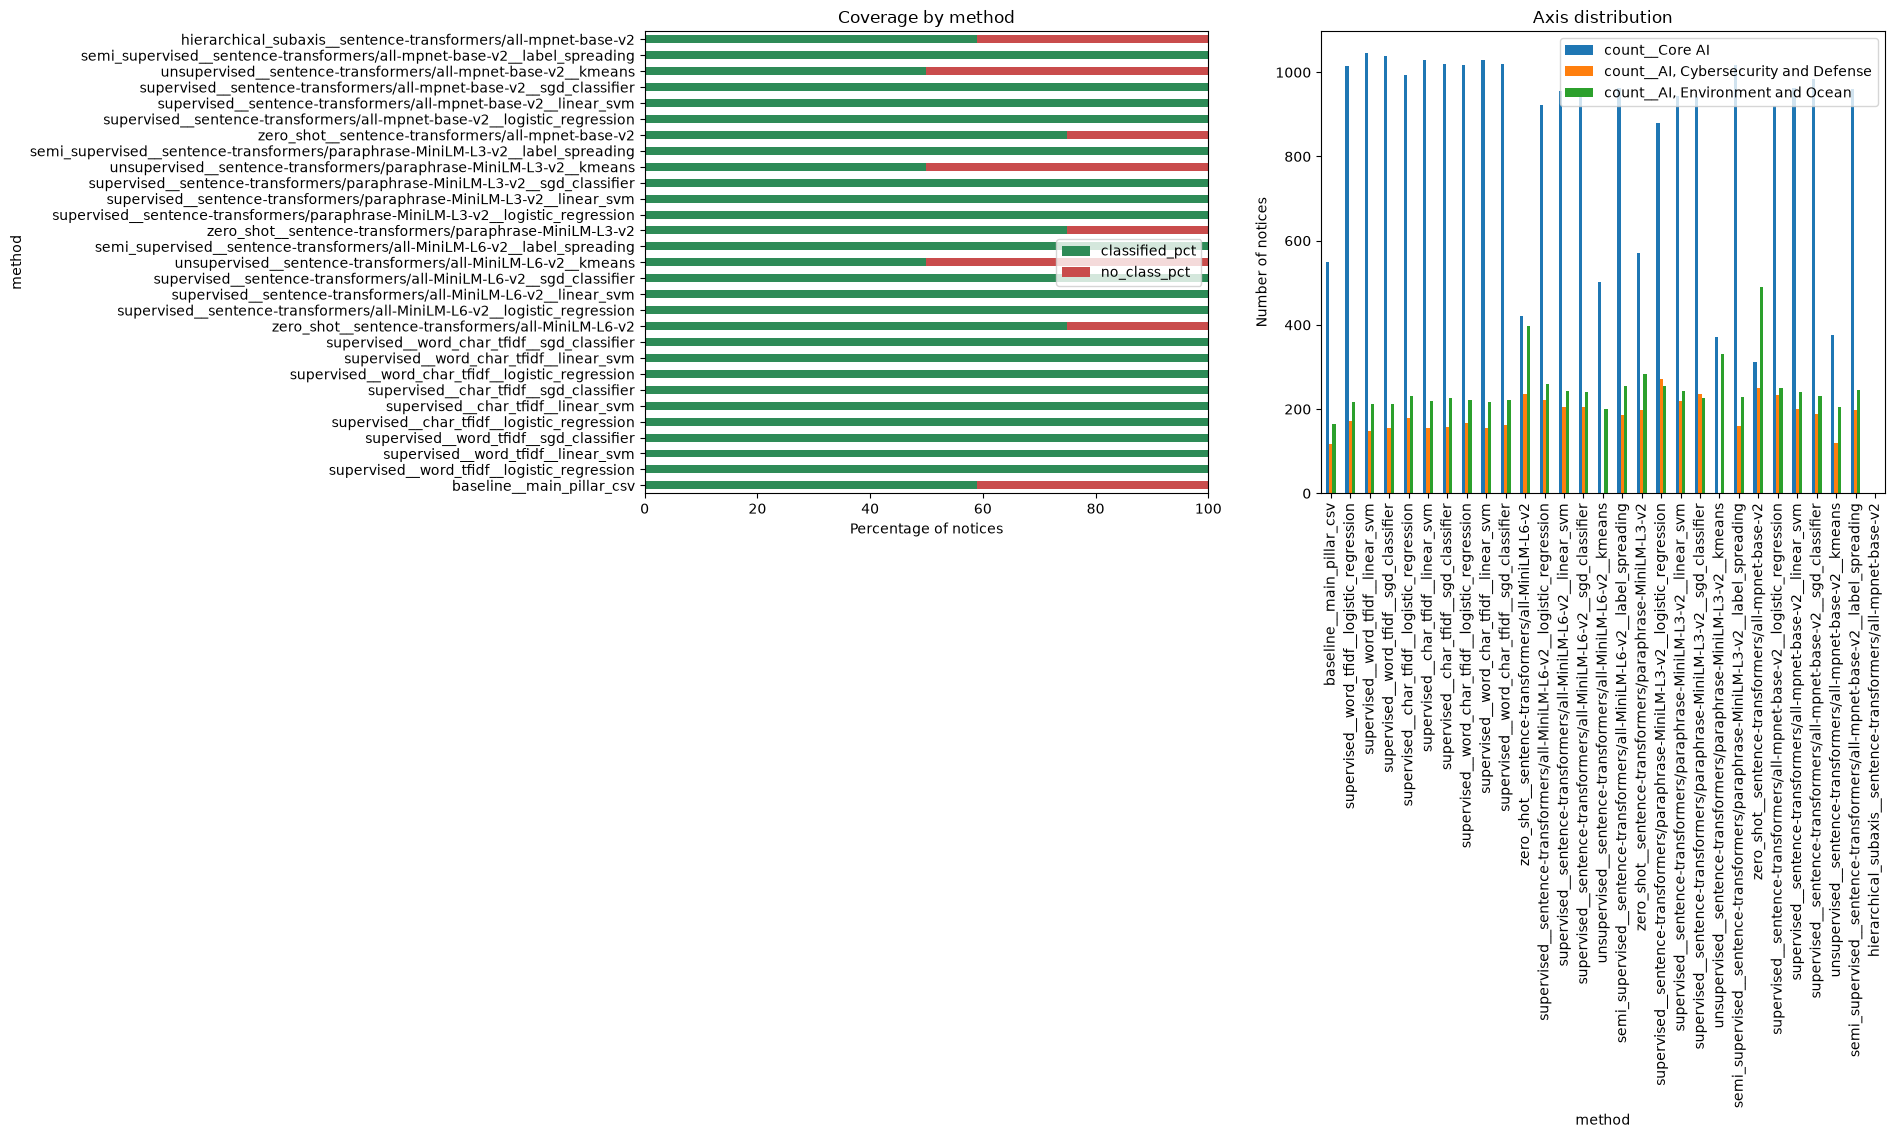

In [146]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
stats_df.set_index("method")[["classified_pct", "no_class_pct"]].plot(kind="barh", stacked=True, ax=axes[0], color=["#2E8B57", "#C94C4C"], title="Coverage by method")
stats_df.set_index("method")[[f"count__{axis}" for axis in axis_names]].plot(kind="bar", ax=axes[1], title="Axis distribution")
axes[0].set_xlabel("Percentage of notices")
axes[1].set_ylabel("Number of notices")
plt.tight_layout()
plt.show()

## 8. CSV and PDF manual-review exports

In [147]:
prediction_export = df[["halId_s", "title_s", "main_pillar", "main_pillar_axis", "baseline_axis", "assigned_pillar", "assigned_subaxis", "subaxis_similarity"]].copy()
for method, prediction in all_predictions.items():
    prediction_export[f"prediction__{method}"] = prediction
    prediction_export[f"confidence__{method}"] = all_confidences[method]
    prediction_export[f"agrees_with_baseline__{method}"] = prediction == df["baseline_axis"].to_numpy()
prediction_export.to_csv("all_methods_predictions.csv", index=False)
hierarchical_counts.to_csv("hierarchical_pillar_subaxis_counts.csv", index=False)
results.to_csv("all_methods_benchmark.csv", index=False)
print("Created all_methods_statistics.csv, all_methods_predictions.csv, all_methods_benchmark.csv, and hierarchical_pillar_subaxis_counts.csv")

Created all_methods_statistics.csv, all_methods_predictions.csv, all_methods_benchmark.csv, and hierarchical_pillar_subaxis_counts.csv


In [148]:
pdf_path = Path("all_methods_review.pdf")
with PdfPages(pdf_path) as pdf:
    for title, frame in [
        ("Method statistics", stats_df),
        ("Benchmark scores", results),
        ("Hierarchical pillar/sub-axis distribution", hierarchical_counts),
    ]:
        fig, ax = plt.subplots(figsize=(15, 7))
        ax.axis("off")
        ax.set_title(title, fontsize=14)
        table = ax.table(cellText=frame.round(3).astype(str).values, colLabels=frame.columns, loc="center")
        table.auto_set_font_size(False)
        table.set_fontsize(6)
        table.scale(1, 1.5)
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)
    best = stats_df.dropna(subset=["test_accuracy"]).sort_values("test_accuracy", ascending=False).iloc[0]["method"]
    disagreements = prediction_export[prediction_export[f"prediction__{best}"] != prediction_export["baseline_axis"]][["halId_s", "title_s", "baseline_axis", f"prediction__{best}", f"confidence__{best}"]]
    for start in range(0, min(len(disagreements), 90), 15):
        page = disagreements.iloc[start:start + 15].copy()
        page["title_s"] = page["title_s"].astype(str).str.slice(0, 90)
        fig, ax = plt.subplots(figsize=(15, 8))
        ax.axis("off")
        ax.set_title(f"Manual review disagreements: {best}")
        table = ax.table(cellText=page.values, colLabels=page.columns, loc="center", cellLoc="left")
        table.auto_set_font_size(False)
        table.set_fontsize(7)
        table.scale(1, 1.6)
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)
print(f"Created {pdf_path}")

Created all_methods_review.pdf


## Dedicated mismatch PDF: CSV baseline vs. MPNet semi-supervised method

The exported PDF contains only the HAL ID, the baseline class from `main_pillar`, and the
Label Spreading prediction produced with `sentence-transformers/all-mpnet-base-v2`.

In [149]:
baseline_method = "baseline__main_pillar_csv"
mpnet_candidates = [
    method for method in all_predictions
    if "semi_supervised__sentence-transformers/all-mpnet-base-v2__label_spreading" in method
]

if not mpnet_candidates:
    raise ValueError(
        "The MPNet semi-supervised method was not generated. "
        "Run the semantic benchmark with USE_PRETRAINED_SEMANTIC = True."
    )

mpnet_method = mpnet_candidates[0]
mismatch_mask = all_predictions[baseline_method] != all_predictions[mpnet_method]
mismatch_pdf = prediction_export.loc[mismatch_mask, ["halId_s"]].copy()
mismatch_pdf["baseline_class"] = all_predictions[baseline_method][mismatch_mask]
mismatch_pdf["mpnet_semi_supervised_class"] = all_predictions[mpnet_method][mismatch_mask]
mismatch_pdf = mismatch_pdf.sort_values("halId_s")

mismatch_pdf_path = Path("baseline_vs_mpnet_semi_supervised_mismatches.pdf")
with PdfPages(mismatch_pdf_path) as pdf:
    if mismatch_pdf.empty:
        pages = [mismatch_pdf]
    else:
        pages = [mismatch_pdf.iloc[start:start + 30] for start in range(0, len(mismatch_pdf), 30)]

    for page in pages:
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.axis("off")
        ax.set_title(
            "Baseline main_pillar vs. MPNet semi-supervised mismatches",
            fontsize=13,
            pad=14,
        )
        if page.empty:
            ax.text(0.5, 0.5, "No mismatches found", ha="center", va="center", fontsize=14)
        else:
            table = ax.table(
                cellText=page.values,
                colLabels=page.columns,
                loc="center",
                cellLoc="left",
            )
            table.auto_set_font_size(False)
            table.set_fontsize(9)
            table.scale(1, 1.6)
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print(f"Created {mismatch_pdf_path} with {len(mismatch_pdf):,} mismatches")
mismatch_pdf

Created baseline_vs_mpnet_semi_supervised_mismatches.pdf with 575 mismatches


,halId_s,baseline_class,mpnet_semi_supervised_class
250,cea-04564147,no class,Core AI
993,hal-03697249,no class,Core AI
72,hal-03972296,no class,Core AI
1305,hal-04122137,no class,Core AI
150,hal-04190553,no class,Core AI
...,...,...,...
806,inserm-04515217,no class,Core AI
203,inserm-05576211,no class,Core AI
1168,tel-04906029,no class,Core AI
1217,tel-05111003,no class,"AI, Cybersecurity and Defense"
